In [10]:
import torch
import numpy as np
from BFM.VI import NGVI
from scipy.stats import t
from BFM.utils import check_marginal_CI_VI
import matplotlib.pyplot as plt

In [2]:
X = np.load('lung.npy')

In [3]:
device1 = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
mu, Cov, mu_eta, np_sigma, v = NGVI(X, device = device1, score = True)

100%|██████████| 50/50 [03:59<00:00,  4.78s/it]


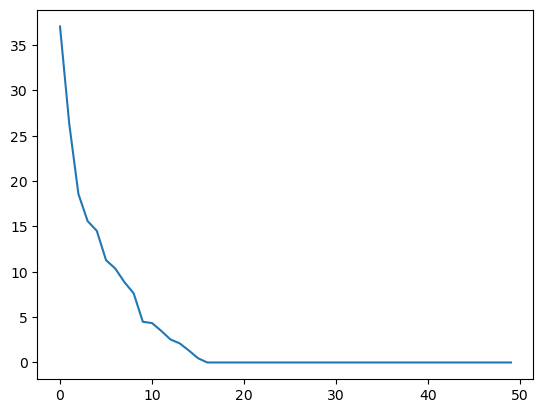

In [5]:
plt.plot(torch.norm(mu, dim = 0).cpu().numpy())
plt.show()

In [6]:
mu_eta = mu_eta.to('cpu').numpy()
Carcinoid = mu_eta[:,0:20]
Colon = mu_eta[:,20:33]
Normal = mu_eta[:,33:50]
SmallCell  = mu_eta[:,50:56]

In [7]:
Var = torch.zeros(5000,50)
for i in range(5000):
    Var[i] = torch.diagonal(Cov[i,:,:])

In [8]:
Var = Var.to('cpu').numpy()
mu = mu.to('cpu').numpy()
v = v.to('cpu').numpy().reshape(-1,1)

In [11]:
zero = check_marginal_CI_VI(mu, Var, v, 0.95)

In [12]:
(5000 - zero.sum(axis = 0)) / 5000

array([0.806 , 0.7162, 0.5268, 0.4284, 0.4338, 0.3636, 0.297 , 0.263 ,
       0.2046, 0.1206, 0.1224, 0.0958, 0.0694, 0.061 , 0.0356, 0.0068,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    ])

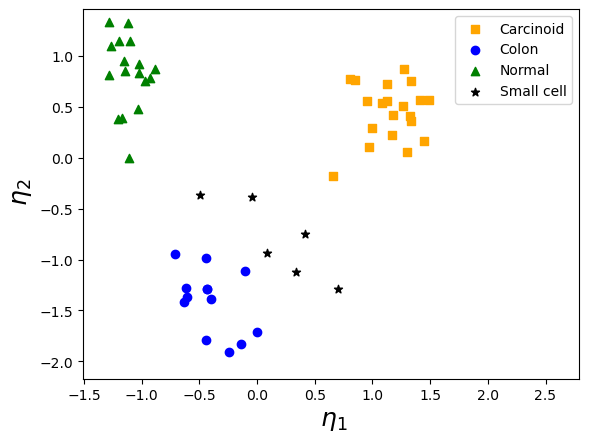

In [14]:
fig, axs = plt.subplots(1, 1)

# First subplot
axs.scatter(Carcinoid[0,:], Carcinoid[1,:], c='orange', marker='s', label='Carcinoid')
axs.scatter(Colon[0,:], Colon[1,:], c='blue', marker='o', label='Colon')
axs.scatter(Normal[0,:], Normal[1,:], c='green', marker='^', label='Normal')
axs.scatter(SmallCell[0,:], SmallCell[1,:], c='black', marker='*', label='Small cell')

# Expand axes by 10–20% beyond data range
margin = 0.40  # 15% padding
x_data = np.concatenate([Carcinoid[0,:], Colon[0,:], Normal[0,:], SmallCell[0,:]])
y_data = np.concatenate([Carcinoid[1,:], Colon[1,:], Normal[1,:], SmallCell[1,:]])
x_min, x_max = x_data.min(), x_data.max()
y_min, y_max = y_data.min(), y_data.max()
x_range = x_max - x_min
y_range = y_max - y_min

axs.set_xlim(x_min - 0.2 * margin * x_range, x_max + 1 * margin * y_range)
axs.set_ylim(y_min - 0.2 * margin * y_range, y_max + 0.1 * margin * y_range)

axs.set_xlabel(r' $ \eta_1 $ ', fontsize=18, fontweight='bold')
axs.set_ylabel(r' $ \eta_2 $ ', fontsize=18, fontweight='bold')
axs.legend(loc='upper right')

plt.show()